# RDKit Snippets We Use Often
### A Complete Entry-Level Tutorial — Learn RDKit in One Notebook

**Author:** Himanshu Goel | [himanshugoel.github.io](https://hgoelgithub.github.io)  
**Repo:** `computational-science-tutorials`

---

## What is RDKit?

**RDKit** is the most widely used open-source cheminformatics library in the world. It is written in C++ with Python bindings and is the backbone of virtually every drug discovery ML pipeline.

### What you will learn in this notebook

| Section | Topics |
|---------|--------|
| 1. Installation & imports | conda, pip, key submodules |
| 2. Molecules: loading & validity | SMILES, SMARTS, InChI, SDF |
| 3. Drawing molecules | 2D/grid views, highlighting atoms |
| 4. Physicochemical descriptors | MW, LogP, TPSA, HBD/HBA, QED |
| 5. Lipinski Ro5 & drug-likeness | rule checking, CNS MPO |
| 6. Fingerprints | Morgan/ECFP, MACCS, RDKit FP |
| 7. Similarity searching | Tanimoto, Dice, bulk search |
| 8. SMARTS substructure search | functional groups, ring systems |
| 9. Scaffold analysis | Murcko decomposition, scaffold trees |
| 10. Standardization | salts, tautomers, canonical SMILES |
| 11. 3D conformers | ETKDG, energy minimization |
| 12. Reading/writing files | SDF, CSV, SMILES files |
| 13. Working with datasets | pandas integration, filtering, QSAR prep |
| 14. Reactions & transformations | SMIRKS, bioisostere swaps |
| 15. Common pitfalls | what to avoid |

---

## Quick Reference Card

```
Chem.MolFromSmiles(smi)          # SMILES → Mol object  (the most used function)
Chem.MolToSmiles(mol)            # Mol → canonical SMILES
Descriptors.MolWt(mol)           # molecular weight
Descriptors.MolLogP(mol)         # cLogP (Wildman-Crippen)
Descriptors.TPSA(mol)            # topological polar surface area
rdMolDescriptors.CalcNumHBD(mol) # H-bond donors
rdMolDescriptors.CalcNumHBA(mol) # H-bond acceptors
gen = AllChem.GetMorganGenerator(radius=2, fpSize=2048); gen.GetFingerprint(mol)  # ECFP4
DataStructs.TanimotoSimilarity(fp1, fp2)  # Tanimoto coefficient
mol.HasSubstructMatch(query)     # substructure search
AllChem.EmbedMolecule(mol)       # generate 3D coordinates
```

---
## Section 1 — Installation & Imports

The recommended way to install RDKit is via **conda** — pip packages exist but conda gives you the full C++ stack without compilation issues.

In [1]:
# ── Installation (run once, then restart kernel) ─────────────────────────────
# Option 1 — conda (recommended)
#   conda create -n rdkit python=3.10
#   conda activate rdkit
#   conda install -c conda-forge rdkit

# Option 2 — pip (Google Colab friendly)
#   pip install rdkit-pypi

# Option 3 — Colab one-liner
#   !pip install rdkit

# ── Core imports ──────────────────────────────────────────────────────────────
from rdkit import Chem                                   # core molecule class
from rdkit.Chem import Descriptors                       # 200+ descriptors
from rdkit.Chem import rdMolDescriptors                  # ring counts, HBD/HBA, etc.
from rdkit.Chem import AllChem                           # fingerprints, 3D conformers
from rdkit.Chem import Draw                              # 2D drawing
from rdkit.Chem import DataStructs                       # similarity metrics
from rdkit.Chem import FilterCatalog                     # PAINS, Brenk filters
from rdkit.Chem import QED                               # quantitative estimate of drug-likeness
from rdkit.Chem import rdMolTransforms                   # geometry / 3D
from rdkit.Chem.MolStandardize import rdMolStandardize  # salt stripping, normalization
from rdkit.Chem.Scaffolds import MurckoScaffold          # scaffold decomposition
from rdkit.Chem import rdChemReactions                   # reactions
from rdkit import DataStructs                            # for BulkTanimotoSimilarity

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

print("RDKit version:", Chem.rdBase.rdkitVersion)
print("All imports successful ✓")

RDKit version: 2025.09.3
All imports successful ✓


---
## Section 2 — Molecules: Loading & Validity

Everything in RDKit starts with a **`Mol` object**. You create it from a SMILES string, SDF file, or InChI. The most common entry point is `Chem.MolFromSmiles()`.

### SMILES quick refresher
SMILES (Simplified Molecular Input Line Entry System) encodes molecular structure as a string:
- `C` = carbon, `N` = nitrogen, `O` = oxygen
- Lowercase = aromatic: `c`, `n`, `o`
- `=` double bond, `#` triple bond
- `()` branches, ring closures by number: `c1ccccc1` = benzene

In [2]:
# ── 2.1 Load from SMILES ──────────────────────────────────────────────────────
aspirin_smi = "CC(=O)Oc1ccccc1C(=O)O"
mol = Chem.MolFromSmiles(aspirin_smi)

# Always check — MolFromSmiles returns None for invalid SMILES!
if mol is None:
    print("Invalid SMILES!")
else:
    print("Molecule loaded:", mol.GetNumAtoms(), "heavy atoms")

Molecule loaded: 13 heavy atoms


In [4]:
# ── 2.2 Canonical SMILES ──────────────────────────────────────────────────────
# RDKit always produces a canonical (unique) SMILES regardless of input order.
# This is critical for deduplication and consistent hashing.

# These three represent the SAME molecule:
smiles_variants = [
    "CC(=O)Oc1ccccc1C(=O)O",    # aspirin variant 1
    "OC(=O)c1ccccc1OC(C)=O",    # variant 2 (different atom order)
    "c1ccc(OC(=O)C)c(C(=O)O)c1", # variant 3
]

for smi in smiles_variants:
    mol = Chem.MolFromSmiles(smi)
    canonical = Chem.MolToSmiles(mol)  # always produces the same string
    print(f"Input:     {smi}")
    print(f"Canonical: {canonical}")
    print()

# ✓ All three produce the same canonical SMILES → safe for deduplication

Input:     CC(=O)Oc1ccccc1C(=O)O
Canonical: CC(=O)Oc1ccccc1C(=O)O

Input:     OC(=O)c1ccccc1OC(C)=O
Canonical: CC(=O)Oc1ccccc1C(=O)O

Input:     c1ccc(OC(=O)C)c(C(=O)O)c1
Canonical: CC(=O)Oc1ccccc1C(=O)O



In [5]:
# ── 2.3 InChI and InChIKey ────────────────────────────────────────────────────
# InChIKey is a 27-character hash — the standard database identifier
# (used by PubChem, ChEMBL, ZINC, etc.)

mol = Chem.MolFromSmiles("CC(=O)Oc1ccccc1C(=O)O")
inchi    = Chem.inchi.MolToInchi(mol)
inchikey = Chem.inchi.InchiToInchiKey(inchi)

print("InChI:   ", inchi)
print("InChIKey:", inchikey)
# Aspirin InChIKey: BSYNRYMUTXBXSQ-UHFFFAOYSA-N  (look it up on PubChem!)

InChI:    InChI=1S/C9H8O4/c1-6(10)13-8-5-3-2-4-7(8)9(11)12/h2-5H,1H3,(H,11,12)
InChIKey: BSYNRYMUTXBXSQ-UHFFFAOYSA-N


In [6]:
# ── 2.4 Validity checking — the defensive pattern ────────────────────────────
# ALWAYS wrap MolFromSmiles in a None check in production code!

def safe_mol(smiles: str):
    """Safe SMILES → Mol conversion with validity check."""
    if not smiles or not isinstance(smiles, str):
        return None
    mol = Chem.MolFromSmiles(smiles.strip())
    if mol is None:
        print(f"  Invalid SMILES: {smiles!r}")
    return mol

test_smiles = [
    "CC(=O)Oc1ccccc1C(=O)O",  # valid: aspirin
    "C1CCCCC1",                # valid: cyclohexane
    "INVALID",                  # invalid: will return None
    "C(C)(",                    # invalid: incomplete
    "",                          # empty string
]

mols = [safe_mol(s) for s in test_smiles]
valid = [m for m in mols if m is not None]
print(f"\nValid: {len(valid)}/{len(test_smiles)} molecules loaded")

  Invalid SMILES: 'INVALID'
  Invalid SMILES: 'C(C)('

Valid: 2/5 molecules loaded


[17:06:35] SMILES Parse Error: syntax error while parsing: INVALID
[17:06:35] SMILES Parse Error: check for mistakes around position 3:
[17:06:35] INVALID
[17:06:35] ~~^
[17:06:35] SMILES Parse Error: Failed parsing SMILES 'INVALID' for input: 'INVALID'
[17:06:35] SMILES Parse Error: syntax error while parsing: C(C)(
[17:06:35] SMILES Parse Error: check for mistakes around position 5:
[17:06:35] C(C)(
[17:06:35] ~~~~^
[17:06:35] SMILES Parse Error: Failed parsing SMILES 'C(C)(' for input: 'C(C)('


In [7]:
# ── 2.5 Atom and bond access ──────────────────────────────────────────────────
mol = Chem.MolFromSmiles("CC(=O)Nc1ccc(O)cc1")  # Paracetamol

print(f"Heavy atoms:  {mol.GetNumAtoms()}")
print(f"Bonds:        {mol.GetNumBonds()}")
print(f"Rings:        {mol.GetRingInfo().NumRings()}")
print()

# Iterate over atoms
print("Atoms:")
for atom in mol.GetAtoms():
    print(f"  Atom {atom.GetIdx():2d}: {atom.GetSymbol():2s}  "
          f"charge={atom.GetFormalCharge()}  "
          f"aromatic={atom.GetIsAromatic()}  "
          f"Hs={atom.GetTotalNumHs()}")

# Iterate over bonds
print("\nBonds:")
for bond in mol.GetBonds():
    print(f"  {bond.GetBeginAtomIdx()} → {bond.GetEndAtomIdx()}  "
          f"type={bond.GetBondTypeAsDouble()}  "
          f"aromatic={bond.GetIsAromatic()}")

Heavy atoms:  11
Bonds:        11
Rings:        1

Atoms:
  Atom  0: C   charge=0  aromatic=False  Hs=3
  Atom  1: C   charge=0  aromatic=False  Hs=0
  Atom  2: O   charge=0  aromatic=False  Hs=0
  Atom  3: N   charge=0  aromatic=False  Hs=1
  Atom  4: C   charge=0  aromatic=True  Hs=0
  Atom  5: C   charge=0  aromatic=True  Hs=1
  Atom  6: C   charge=0  aromatic=True  Hs=1
  Atom  7: C   charge=0  aromatic=True  Hs=0
  Atom  8: O   charge=0  aromatic=False  Hs=1
  Atom  9: C   charge=0  aromatic=True  Hs=1
  Atom 10: C   charge=0  aromatic=True  Hs=1

Bonds:
  0 → 1  type=1.0  aromatic=False
  1 → 2  type=2.0  aromatic=False
  1 → 3  type=1.0  aromatic=False
  3 → 4  type=1.0  aromatic=False
  4 → 5  type=1.5  aromatic=True
  5 → 6  type=1.5  aromatic=True
  6 → 7  type=1.5  aromatic=True
  7 → 8  type=1.0  aromatic=False
  7 → 9  type=1.5  aromatic=True
  9 → 10  type=1.5  aromatic=True
  10 → 4  type=1.5  aromatic=True


---
## Section 3 — Drawing Molecules

RDKit has a built-in 2D drawing engine. In Jupyter notebooks you get inline SVG/PNG rendering.

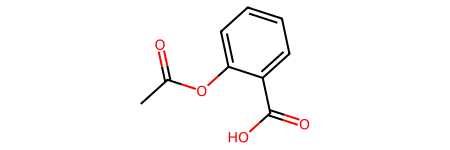

In [8]:
# ── 3.1 Draw a single molecule (inline in Jupyter) ───────────────────────────
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
IPythonConsole.ipython_useSVG = True  # SVG is crisper than PNG

mol = Chem.MolFromSmiles("CC(=O)Oc1ccccc1C(=O)O")  # Aspirin
mol  # just type the mol object — Jupyter renders it automatically

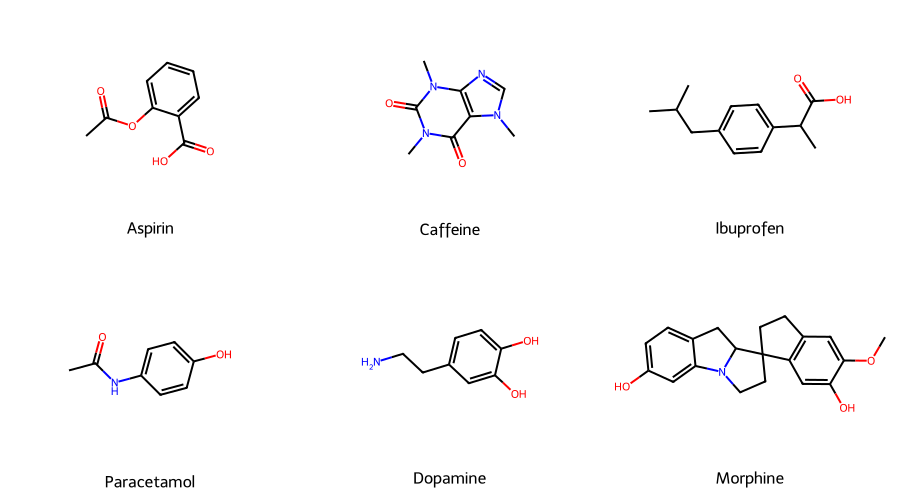

In [9]:
# ── 3.2 Draw a grid of molecules ──────────────────────────────────────────────
# The most useful function for dataset exploration!

drug_smiles = {
    "Aspirin":      "CC(=O)Oc1ccccc1C(=O)O",
    "Caffeine":     "Cn1cnc2c1c(=O)n(C)c(=O)n2C",
    "Ibuprofen":    "CC(C)Cc1ccc(cc1)C(C)C(=O)O",
    "Paracetamol":  "CC(=O)Nc1ccc(O)cc1",
    "Dopamine":     "NCCc1ccc(O)c(O)c1",
    "Morphine":     "OC1=CC=C2CC3N(CCC34CCc5c4cc(O)c(OC)c5)C2=C1",
}

mols   = [Chem.MolFromSmiles(s) for s in drug_smiles.values()]
labels = list(drug_smiles.keys())

img = Draw.MolsToGridImage(
    mols,
    molsPerRow=3,
    subImgSize=(300, 250),
    legends=labels,
)
img

Amide atom indices: (1, 2, 3)


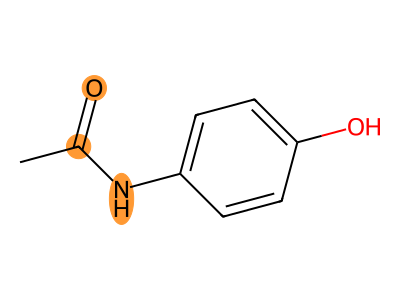

In [10]:
# ── 3.3 Highlight atoms and bonds ────────────────────────────────────────────
# Very useful for showing substructure matches, SHAP-important atoms, etc.

mol   = Chem.MolFromSmiles("CC(=O)Nc1ccc(O)cc1")  # Paracetamol
query = Chem.MolFromSmarts("[CX3](=O)[NX3]")       # amide SMARTS

# Find matching atom indices
match = mol.GetSubstructMatch(query)  # returns first match
print("Amide atom indices:", match)

# Highlight those atoms in the drawing
img = Draw.MolToImage(
    mol,
    size=(400, 300),
    highlightAtoms=list(match),
    highlightColor=(1.0, 0.6, 0.2),  # orange
)
img

In [11]:
# ── 3.4 Save to file ──────────────────────────────────────────────────────────
mol = Chem.MolFromSmiles("Cn1cnc2c1c(=O)n(C)c(=O)n2C")  # Caffeine

# Save as PNG
Draw.MolToFile(mol, "caffeine.png", size=(400, 300))

# Save as SVG (vector — scales perfectly for papers/slides)
from rdkit.Chem.Draw import rdMolDraw2D
drawer = rdMolDraw2D.MolDraw2DSVG(400, 300)
drawer.DrawMolecule(mol)
drawer.FinishDrawing()
svg_text = drawer.GetDrawingText()
with open("caffeine.svg", "w") as f:
    f.write(svg_text)
print("Saved caffeine.png and caffeine.svg")

Saved caffeine.png and caffeine.svg


---
## Section 4 — Physicochemical Descriptors

Descriptors are numerical features that characterise a molecule. RDKit computes **200+ descriptors** from the `Descriptors` module.

The most important ones for drug discovery:

In [14]:
# ── 4.1 The core descriptors you will use 90% of the time ───────────────────
def compute_descriptors(smiles):
    """Compute the most commonly used drug-likeness descriptors."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return {
        # Lipinski Ro5
        "MW":      round(Descriptors.MolWt(mol), 2),           # molecular weight
        "ExactMW": round(Descriptors.ExactMolWt(mol), 4),      # monoisotopic mass
        "LogP":    round(Descriptors.MolLogP(mol), 3),          # cLogP (Wildman-Crippen)
        "HBD":     rdMolDescriptors.CalcNumHBD(mol),            # H-bond donors
        "HBA":     rdMolDescriptors.CalcNumHBA(mol),            # H-bond acceptors
        # Veber rules
        "TPSA":    round(Descriptors.TPSA(mol), 2),             # topological polar surface area
        "RotBonds":rdMolDescriptors.CalcNumRotatableBonds(mol), # rotatable bonds
        # Structure
        "Rings":   rdMolDescriptors.CalcNumRings(mol),          # total ring count
        "ArRings": rdMolDescriptors.CalcNumAromaticRings(mol),  # aromatic rings
        "HeavyAt": mol.GetNumHeavyAtoms(),                      # heavy atom count
        "Fsp3":    round(rdMolDescriptors.CalcFractionCSP3(mol),3), # fraction sp3 carbons
        # Drug-likeness score
        "QED":     round(QED.qed(mol), 4),                       # 0–1, higher = more drug-like
        # Formula
        "Formula": rdMolDescriptors.CalcMolFormula(mol),
    }

# Test on aspirin
desc = compute_descriptors("CC(=O)Oc1ccccc1C(=O)O")
for k, v in desc.items():
    print(f"  {k:12s}: {v}")

  MW          : 180.16
  ExactMW     : 180.0423
  LogP        : 1.31
  HBD         : 1
  HBA         : 3
  TPSA        : 63.6
  RotBonds    : 2
  Rings       : 1
  ArRings     : 1
  HeavyAt     : 13
  Fsp3        : 0.111
  QED         : 0.5501
  Formula     : C9H8O4


In [15]:
# ── 4.2 Build a descriptor table for a library ───────────────────────────────
drug_library = {
    "Aspirin":      "CC(=O)Oc1ccccc1C(=O)O",
    "Caffeine":     "Cn1cnc2c1c(=O)n(C)c(=O)n2C",
    "Ibuprofen":    "CC(C)Cc1ccc(cc1)C(C)C(=O)O",
    "Paracetamol":  "CC(=O)Nc1ccc(O)cc1",
    "Dopamine":     "NCCc1ccc(O)c(O)c1",
    "Sildenafil":   "CCCC1=NN(C)C(=O)c2cc(cnc21)c1ccc(cc1)S(=O)(=O)N1CCN(C)CC1",
    "Atorvastatin": "CC(C)c1c(C(=O)Nc2ccccc2F)c(-c2ccccc2)c(-c2ccc(F)cc2)n1CCC(O)CC(O)CC(=O)O",
}

rows = []
for name, smi in drug_library.items():
    desc = compute_descriptors(smi)
    if desc:
        desc["Name"] = name
        rows.append(desc)

df = pd.DataFrame(rows).set_index("Name")
cols_show = ["MW", "LogP", "HBD", "HBA", "TPSA", "RotBonds", "Fsp3", "QED", "Formula"]
print(df[cols_show].to_string())

                  MW   LogP  HBD  HBA    TPSA  RotBonds   Fsp3     QED       Formula
Name                                                                                
Aspirin       180.16  1.310    1    3   63.60         2  0.111  0.5501        C9H8O4
Caffeine      194.19 -1.029    0    6   61.82         0  0.375  0.5385     C8H10N4O2
Ibuprofen     206.28  3.073    1    1   37.30         4  0.462  0.8216      C13H18O2
Paracetamol   151.16  1.351    2    2   49.33         1  0.125  0.5950       C8H9NO2
Dopamine      153.18  0.599    3    3   66.48         2  0.250  0.5449      C8H11NO2
Sildenafil    441.56  1.884    0    7   88.40         5  0.409  0.6008   C22H27N5O3S
Atorvastatin  576.64  6.453    4    5  111.79        12  0.273  0.1549  C33H34F2N2O5


In [18]:
# ── 4.3 All 200+ descriptors — how to access them ────────────────────────────
mol = Chem.MolFromSmiles("CC(=O)Oc1ccccc1C(=O)O")

# Get the complete list of available descriptor names
all_desc_names = [name for name, fn in Descriptors.descList]
print(f"Total available descriptors: {len(all_desc_names)}")
print("Sample names:", all_desc_names[:10])

# Compute ALL descriptors at once (returns dict)
from rdkit.ML.Descriptors import MoleculeDescriptors
calc = MoleculeDescriptors.MolecularDescriptorCalculator(all_desc_names)
values = calc.CalcDescriptors(mol)
full_desc = dict(zip(all_desc_names, values))
print(f"\nComputed {len(full_desc)} descriptor values")
print("First 10:", list(full_desc.items())[:10])

Total available descriptors: 217
Sample names: ['MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons']

Computed 217 descriptor values
First 10: [('MaxAbsEStateIndex', np.float64(10.611948223733938)), ('MaxEStateIndex', np.float64(10.611948223733938)), ('MinAbsEStateIndex', np.float64(0.01601851851851821)), ('MinEStateIndex', np.float64(-1.1140277777777776)), ('qed', 0.5501217966938848), ('SPS', 9.307692307692308), ('MolWt', 180.15899999999996), ('HeavyAtomMolWt', 172.09499999999997), ('ExactMolWt', 180.042258736), ('NumValenceElectrons', 68)]


---
## Section 5 — Lipinski Ro5 & Drug-Likeness Rules

**Lipinski's Rule of Five** (1997) predicts oral bioavailability — a compound is likely orally bioavailable if it satisfies at most 1 violation:
- MW ≤ 500 Da
- LogP ≤ 5
- HBD ≤ 5
- HBA ≤ 10

In [19]:
# ── 5.1 Lipinski Ro5 checker ──────────────────────────────────────────────────
def lipinski_ro5(smiles):
    """Check Lipinski Rule of Five. Returns dict with pass/fail per rule."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    mw   = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd  = rdMolDescriptors.CalcNumHBD(mol)
    hba  = rdMolDescriptors.CalcNumHBA(mol)

    rules = {
        "MW ≤ 500":   (mw   <= 500, f"MW = {mw:.1f}"),
        "LogP ≤ 5":   (logp <=   5, f"LogP = {logp:.2f}"),
        "HBD ≤ 5":    (hbd  <=   5, f"HBD = {hbd}"),
        "HBA ≤ 10":   (hba  <=  10, f"HBA = {hba}"),
    }

    violations = sum(1 for passed, _ in rules.values() if not passed)
    return {
        "rules":      rules,
        "violations": violations,
        "ro5_pass":   violations <= 1,  # ≤1 violation allowed
    }

# Test a few drugs
test_drugs = {
    "Aspirin":       "CC(=O)Oc1ccccc1C(=O)O",
    "Atorvastatin":  "CC(C)c1c(C(=O)Nc2ccccc2F)c(-c2ccccc2)c(-c2ccc(F)cc2)n1CCC(O)CC(O)CC(=O)O",
    "Cyclosporin A": "CCC1NC(=O)C(CC2CCCCC2)N(C)C(=O)C(C(C)CC)N(C)C(=O)C2CCCN2C(=O)C(CC(C)C)NC(=O)C(CC(C)C)N(C)C(=O)C(C)NC(=O)C(C)NC(=O)C(CC(C)C)N(C)C(=O)C(CC(C)C)NC(=O)C(CO)N(C)C1=O",
}

for name, smi in test_drugs.items():
    result = lipinski_ro5(smi)
    status = "✓ PASS" if result["ro5_pass"] else "✗ FAIL"
    print(f"\n{name} [{status}] — {result['violations']} violation(s)")
    for rule, (passed, value) in result["rules"].items():
        icon = "  ✓" if passed else "  ✗"
        print(f"  {icon} {rule:12s}  {value}")


Aspirin [✓ PASS] — 0 violation(s)
    ✓ MW ≤ 500      MW = 180.2
    ✓ LogP ≤ 5      LogP = 1.31
    ✓ HBD ≤ 5       HBD = 1
    ✓ HBA ≤ 10      HBA = 3

Atorvastatin [✗ FAIL] — 2 violation(s)
    ✗ MW ≤ 500      MW = 576.6
    ✗ LogP ≤ 5      LogP = 6.45
    ✓ HBD ≤ 5       HBD = 4
    ✓ HBA ≤ 10      HBA = 5

Cyclosporin A [✗ FAIL] — 3 violation(s)
    ✗ MW ≤ 500      MW = 1200.6
    ✓ LogP ≤ 5      LogP = 3.19
    ✗ HBD ≤ 5       HBD = 6
    ✗ HBA ≤ 10      HBA = 12


In [20]:
# ── 5.2 Extended drug-likeness rules ─────────────────────────────────────────
def drug_profile(smiles):
    """Comprehensive drug-likeness profile."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    mw   = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd  = rdMolDescriptors.CalcNumHBD(mol)
    hba  = rdMolDescriptors.CalcNumHBA(mol)
    tpsa = Descriptors.TPSA(mol)
    rb   = rdMolDescriptors.CalcNumRotatableBonds(mol)
    ar   = rdMolDescriptors.CalcNumAromaticRings(mol)
    fsp3 = rdMolDescriptors.CalcFractionCSP3(mol)
    qed  = QED.qed(mol)

    return {
        # Lipinski Ro5 (oral bioavailability)
        "Ro5":         sum([mw>500, logp>5, hbd>5, hba>10]) <= 1,
        # Veber rules (oral bioavailability — TPSA + rotatable bonds)
        "Veber":       tpsa <= 140 and rb <= 10,
        # Lead-like (Teague 1999) — tighter than Ro5 for lead optimisation
        "Lead-like":   200 <= mw <= 450 and logp <= 4 and rb <= 7,
        # Fragment-like (Ro3) — for fragment-based drug discovery
        "Fragment Ro3":mw <= 300 and logp <= 3 and hbd <= 3 and hba <= 3,
        # CNS MPO — Pfizer CNS multi-parameter optimisation score
        "CNS MPO":     sum([
            mw      <= 360,
            logp    >=  1  and logp  <= 3,
            tpsa    <= 90,
            hbd     ==  0  or  hbd   == 1,
            logp    <   5,
            ar      <=  2,
        ]),  # out of 6 — CNS drugs typically score 4–6
        # QED score (Bickerton 2012) — holistic drug-likeness 0–1
        "QED":         round(qed, 3),
        "QED grade":   "Excellent" if qed>0.7 else "Good" if qed>0.5 else "Moderate" if qed>0.3 else "Poor",
    }

drugs = {
    "Aspirin":       "CC(=O)Oc1ccccc1C(=O)O",
    "Caffeine":      "Cn1cnc2c1c(=O)n(C)c(=O)n2C",
    "Ibuprofen":     "CC(C)Cc1ccc(cc1)C(C)C(=O)O",
    "Sildenafil":    "CCCC1=NN(C)C(=O)c2cc(cnc21)c1ccc(cc1)S(=O)(=O)N1CCN(C)CC1",
}
for name, smi in drugs.items():
    profile = drug_profile(smi)
    print(f"{name:15s}: Ro5={profile['Ro5']}  Veber={profile['Veber']}  "
          f"LeadLike={profile['Lead-like']}  CNS_MPO={profile['CNS MPO']}/6  "
          f"QED={profile['QED']} ({profile['QED grade']})")

Aspirin        : Ro5=True  Veber=True  LeadLike=False  CNS_MPO=6/6  QED=0.55 (Good)
Caffeine       : Ro5=True  Veber=True  LeadLike=False  CNS_MPO=5/6  QED=0.538 (Good)
Ibuprofen      : Ro5=True  Veber=True  LeadLike=True  CNS_MPO=5/6  QED=0.822 (Excellent)
Sildenafil     : Ro5=True  Veber=True  LeadLike=True  CNS_MPO=4/6  QED=0.601 (Good)


---
## Section 6 — Molecular Fingerprints

Fingerprints are **binary or count vectors** that encode molecular structure. They are the primary input to most ML models for molecular property prediction.

### Types of fingerprints
| Fingerprint | Type | Best for |
|---|---|---|
| Morgan / ECFP | Circular (radius) | ML models, similarity, most common |
| MACCS Keys | 166-bit structural keys | Interpretable, regulatory |
| RDKit FP | Path-based | Legacy, fast |
| Atom Pairs | Topological | 3D-free shape |
| Topological Torsion | 4-atom paths | Shape/conformer |

**ECFP4 = Morgan fingerprint with radius=2.** This is the most commonly used fingerprint in cheminformatics.

In [37]:
# ── 6.1 Morgan / ECFP fingerprint ────────────────────────────────────────────
mol = Chem.MolFromSmiles("CC(=O)Oc1ccccc1C(=O)O")  # Aspirin

# ECFP4 (radius=2) — 2048-bit — the standard for ML
gen = AllChem.GetMorganGenerator(radius=2, fpSize=2048)
ecfp4 = gen.GetFingerprint(mol)
print(f"ECFP4: type={type(ecfp4)}")
print(f"  Length:   {len(ecfp4)} bits")
print(f"  On bits:  {ecfp4.GetNumOnBits()}  (density = {ecfp4.GetNumOnBits()/len(ecfp4):.3f})")
print(f"  Bit string (first 64): {ecfp4.ToBitString()[:64]}...")

# Convert to numpy array (needed for ML models)
import numpy as np
arr = np.array(ecfp4)
print(f"\nNumpy array shape: {arr.shape}, dtype: {arr.dtype}")

# ECFP6 (radius=3) — captures larger chemical environment
gen_ecfp6 = AllChem.GetMorganGenerator(radius=3, fpSize=2048)
ecfp6 = gen_ecfp6.GetFingerprint(mol)
print(f"\nECFP6 on bits: {ecfp6.GetNumOnBits()}")

ECFP4: type=<class 'rdkit.DataStructs.cDataStructs.ExplicitBitVect'>
  Length:   2048 bits
  On bits:  24  (density = 0.012)
  Bit string (first 64): 0000000000000000000000000000000000000000000000000000000000000000...

Numpy array shape: (2048,), dtype: int64

ECFP6 on bits: 31


In [38]:
# ── 6.2 Count fingerprint vs bit fingerprint ──────────────────────────────────
# Bit FP: bit is ON if any atom environment hashes to that bit
# Count FP: stores how many atom environments hash to each bit
# Count FP is slightly more informative; bit FP is more common

mol = Chem.MolFromSmiles("c1ccc2ccccc2c1")  # Naphthalene (repeated substructure)

# Bit fingerprint
gen_bit = AllChem.GetMorganGenerator(radius=2, fpSize=2048)
fp_bit = gen_bit.GetFingerprint(mol)

# Count fingerprint
gen_count = AllChem.GetMorganGenerator(radius=2)
fp_count = gen_count.GetCountFingerprint(mol)  # count fingerprint (sparse format)

print("Bit FP on bits:", fp_bit.GetNumOnBits())
print("Count FP elements:", len(fp_count.GetNonzeroElements()))
print("Count FP non-zero:", dict(list(fp_count.GetNonzeroElements().items())[:5]))

Bit FP on bits: 8
Count FP elements: 8
Count FP non-zero: {598: 2, 1087: 4, 1088: 4, 1199: 4, 1380: 2}


In [23]:
# ── 6.3 MACCS Keys (166-bit structural keys) ──────────────────────────────────
# MACCS keys are human-readable: each bit corresponds to a defined SMARTS pattern.
# More interpretable than Morgan, less powerful for ML.

mol = Chem.MolFromSmiles("CC(=O)Oc1ccccc1C(=O)O")  # Aspirin
maccs = rdMolDescriptors.GetMACCSKeysFingerprint(mol)

print(f"MACCS: {len(maccs)} bits, {maccs.GetNumOnBits()} on")

# The on-bits correspond to specific structural features
on_bits = list(maccs.GetOnBits())
print(f"On bit indices: {on_bits}")
# Bit 166 = has ring, bit 125 = ester/carboxylic acid, etc.

MACCS: 167 bits, 21 on
On bit indices: [89, 113, 123, 126, 127, 136, 139, 140, 143, 144, 146, 150, 152, 154, 157, 159, 160, 162, 163, 164, 165]


In [34]:
# ── 6.4 Convert library to fingerprint matrix (for ML) ───────────────────────
# This is the core pattern for preparing data for scikit-learn, XGBoost, etc.

smiles_list = [
    "CC(=O)Oc1ccccc1C(=O)O",          # Aspirin
    "Cn1cnc2c1c(=O)n(C)c(=O)n2C",    # Caffeine
    "CC(C)Cc1ccc(cc1)C(C)C(=O)O",    # Ibuprofen
    "CC(=O)Nc1ccc(O)cc1",             # Paracetamol
    "NCCc1ccc(O)c(O)c1",              # Dopamine
]

def smiles_to_fingerprint_matrix(smiles_list, radius=2, n_bits=2048):
    """Convert list of SMILES to numpy fingerprint matrix (N × n_bits)."""
    fps = []
    valid_smiles = []
    gen = AllChem.GetMorganGenerator(radius=radius, fpSize=n_bits)
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            fp = gen.GetFingerprint(mol)
            fps.append(np.array(fp))
            valid_smiles.append(smi)
    return np.array(fps), valid_smiles

X, valid = smiles_to_fingerprint_matrix(smiles_list)
print(f"Fingerprint matrix shape: {X.shape}")
print(f"  {X.shape[0]} molecules × {X.shape[1]} bits")
print(f"  Density (mean fraction on): {X.mean():.4f}")
print(f"\nReady to pass to sklearn: RandomForestClassifier().fit(X, y)")

Fingerprint matrix shape: (5, 2048)
  5 molecules × 2048 bits
  Density (mean fraction on): 0.0112

Ready to pass to sklearn: RandomForestClassifier().fit(X, y)


---
## Section 7 — Similarity Searching

**Tanimoto similarity** (also called Jaccard) is the standard measure of molecular similarity:

$$T(A, B) = \frac{|A \cap B|}{|A \cup B|} = \frac{c}{a + b - c}$$

where `a` = bits in A, `b` = bits in B, `c` = bits in both.  
Range: 0 (completely different) to 1 (identical).

| Tanimoto | Interpretation |
|---|---|
| ≥ 0.85 | Essentially the same scaffold |
| 0.65–0.85 | Close analog |
| 0.40–0.65 | Distant analog |
| < 0.40 | Structurally unrelated |

In [49]:
# ── 7.1 Tanimoto similarity between two molecules ────────────────────────────
from rdkit import DataStructs

def tanimoto(smi1, smi2, radius=2, n_bits=2048):
    """Compute Tanimoto similarity between two SMILES."""
    mol1 = Chem.MolFromSmiles(smi1)
    mol2 = Chem.MolFromSmiles(smi2)
    if mol1 is None or mol2 is None:
        return None
    gen = AllChem.GetMorganGenerator(radius=radius, fpSize=n_bits)
    fp1 = gen.GetFingerprint(mol1)
    fp2 = gen.GetFingerprint(mol2)
    return DataStructs.TanimotoSimilarity(fp1, fp2)

# Compare opioids — structurally related drugs should be similar
pairs = [
    ("Morphine",  "OC1=CC=C2CC3N(CCC34CCc5c4cc(O)c(OC)c5)C2=C1"),
    ("Codeine",   "CN1CC[C@]23[C@@H]4[C@H]([C@@H]5C[C@@H](C[C@H]2[C@H]31)OC)OC4=C5c6ccccc6"),
    ("Heroin",    "CC(=O)O[C@H]1C=C[C@H]2[C@H]3CC4=C5[C@]2([C@H]1OC5=C(C=C4)OC(=O)C)CCN3C"),
    ("Naloxone",  "OC1=CC=C2CC3N(CC(=C)CCC34CCc5c4cc(O)c(O)c5)C2=C1"),
    ("Ibuprofen", "CC(C)Cc1ccc(cc1)C(C)C(=O)O"),  # unrelated
]

morphine_smi = pairs[0][1]
print("Similarity to Morphine:")
for name, smi in pairs:
    tc = tanimoto(morphine_smi, smi)
    if tc is None:
        bar = ""
        tc = 0.0
    else:
        bar = "█" * int(tc * 30)
    print(f"  {name:12s}: {tc:.4f}  {bar}")

Similarity to Morphine:
  Morphine    : 1.0000  ██████████████████████████████
  Codeine     : 0.1429  ████
  Heroin      : 0.1860  █████
  Naloxone    : 0.5965  █████████████████
  Ibuprofen   : 0.0746  ██


Tanimoto similarity matrix:
           Morphine  Codeine  Naloxone  Aspirin  Ibuprofen
Morphine      1.000    0.143     0.596    0.109      0.075
Codeine       0.143    1.000     0.094    0.123      0.072
Naloxone      0.596    0.094     1.000    0.062      0.062
Aspirin       0.109    0.123     0.062    1.000      0.195
Ibuprofen     0.075    0.072     0.062    0.195      1.000


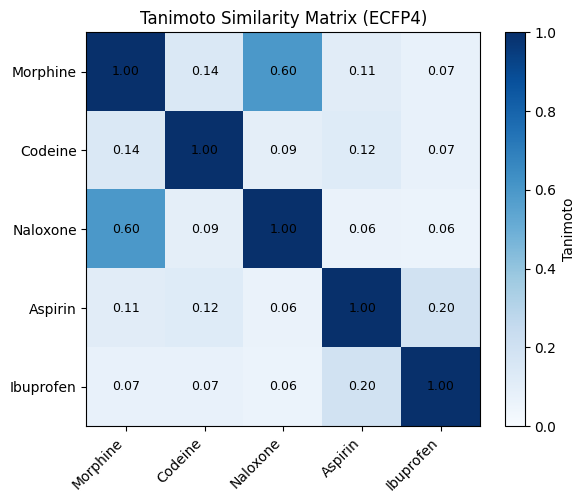

In [50]:
# ── 7.2 Similarity matrix for a set of molecules ────────────────────────────
drug_smiles = {
    "Morphine":  "OC1=CC=C2CC3N(CCC34CCc5c4cc(O)c(OC)c5)C2=C1",
    "Codeine":   "CN1CC[C@]23[C@@H]4[C@H]([C@@H]5C[C@@H](C[C@H]2[C@H]31)OC)OC4=C5c6ccccc6",
    "Naloxone":  "OC1=CC=C2CC3N(CC(=C)CCC34CCc5c4cc(O)c(O)c5)C2=C1",
    "Aspirin":   "CC(=O)Oc1ccccc1C(=O)O",
    "Ibuprofen": "CC(C)Cc1ccc(cc1)C(C)C(=O)O",
}

names = list(drug_smiles.keys())
gen = AllChem.GetMorganGenerator(radius=2, fpSize=2048)
fps = [
    gen.GetFingerprint(Chem.MolFromSmiles(s))
    for s in drug_smiles.values()
]

n = len(fps)
sim_matrix = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        sim_matrix[i, j] = DataStructs.TanimotoSimilarity(fps[i], fps[j])

sim_df = pd.DataFrame(sim_matrix, index=names, columns=names)
print("Tanimoto similarity matrix:")
print(sim_df.round(3).to_string())

# Quick heatmap
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(sim_matrix, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(range(n)); ax.set_xticklabels(names, rotation=45, ha='right')
ax.set_yticks(range(n)); ax.set_yticklabels(names)
plt.colorbar(im, ax=ax, label='Tanimoto')
for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{sim_matrix[i,j]:.2f}", ha='center', va='center', fontsize=9)
ax.set_title("Tanimoto Similarity Matrix (ECFP4)")
plt.tight_layout()
plt.show()

In [52]:
# ── 7.3 Bulk similarity — fast nearest-neighbor search ───────────────────────
# BulkTanimotoSimilarity is MUCH faster than looping TanimotoSimilarity
# Use this when searching a query against a large library!

query_smi = "CC(=O)Oc1ccccc1C(=O)O"   # Aspirin
library   = [
    "CC(=O)Oc1ccccc1C(=O)O",          # Aspirin (identical)
    "CC(=O)Nc1ccc(O)cc1",             # Paracetamol (NSAID analog)
    "CC(C)Cc1ccc(cc1)C(C)C(=O)O",    # Ibuprofen
    "O=C(O)c1ccccc1",                  # Benzoic acid (partial scaffold)
    "Cn1cnc2c1c(=O)n(C)c(=O)n2C",    # Caffeine (unrelated)
    "NCCc1ccc(O)c(O)c1",              # Dopamine (unrelated)
]

gen = AllChem.GetMorganGenerator(radius=2, fpSize=2048)
query_fp  = gen.GetFingerprint(Chem.MolFromSmiles(query_smi))
lib_fps   = [
    gen.GetFingerprint(Chem.MolFromSmiles(s))
    for s in library
]

# Single call — returns list of floats
similarities = DataStructs.BulkTanimotoSimilarity(query_fp, lib_fps)

---
## Section 8 — SMARTS Substructure Search

**SMARTS** (SMILES Arbitrary Target Specification) extends SMILES with wildcards and logical operators for defining **structural patterns** to search for.

SMARTS is how you ask: "does this molecule contain a carboxylic acid?" or "does it have a Michael acceptor?"

### Key SMARTS syntax
| SMARTS | Matches |
|---|---|
| `[CX3](=O)[OX2H1]` | Carboxylic acid |
| `[NX3;H2]` | Primary amine |
| `[CX3](=O)[NX3]` | Amide |
| `c1ccccc1` | Benzene ring |
| `[#6]` | Any carbon |
| `[!#1]` | Any non-hydrogen atom |

In [53]:
# ── 8.1 Basic substructure search ────────────────────────────────────────────
mol   = Chem.MolFromSmiles("CC(=O)Nc1ccc(O)cc1")  # Paracetamol

# SMARTS patterns for common functional groups
patterns = {
    "Carboxylic acid":  Chem.MolFromSmarts("[CX3](=O)[OX2H1]"),
    "Ester":            Chem.MolFromSmarts("[CX3](=O)[OX2][#6]"),
    "Amide":            Chem.MolFromSmarts("[CX3](=O)[NX3H]"),
    "Primary amine":    Chem.MolFromSmarts("[NX3;H2;!$(NC=O)]"),
    "Hydroxyl":         Chem.MolFromSmarts("[OX2H]"),
    "Aromatic ring":    Chem.MolFromSmarts("c1ccccc1"),
    "Phenol":           Chem.MolFromSmarts("[OX2H]c"),
}

print(f"Paracetamol functional groups:")
for name, patt in patterns.items():
    has = mol.HasSubstructMatch(patt)
    icon = "✓" if has else "✗"
    matches = mol.GetSubstructMatches(patt)  # all matches (not just first)
    print(f"  {icon} {name:20s}  {len(matches)} match(es)")

Paracetamol functional groups:
  ✗ Carboxylic acid       0 match(es)
  ✗ Ester                 0 match(es)
  ✓ Amide                 1 match(es)
  ✗ Primary amine         0 match(es)
  ✓ Hydroxyl              1 match(es)
  ✓ Aromatic ring         1 match(es)
  ✓ Phenol                1 match(es)


In [54]:
# ── 8.2 Filter a library by substructure ─────────────────────────────────────
# Very common pattern: keep only compounds matching (or not matching) a pattern

library = [
    ("Aspirin",      "CC(=O)Oc1ccccc1C(=O)O"),
    ("Paracetamol",  "CC(=O)Nc1ccc(O)cc1"),
    ("Ibuprofen",    "CC(C)Cc1ccc(cc1)C(C)C(=O)O"),
    ("Glycine",      "NCC(=O)O"),
    ("Aniline",      "Nc1ccccc1"),
    ("Caffeine",     "Cn1cnc2c1c(=O)n(C)c(=O)n2C"),
]

# Find all molecules containing a carboxylic acid
acid_patt = Chem.MolFromSmarts("[CX3](=O)[OX2H1]")

print("Contains carboxylic acid:")
for name, smi in library:
    mol = Chem.MolFromSmiles(smi)
    has = mol.HasSubstructMatch(acid_patt)
    print(f"  {'✓' if has else '✗'} {name}")

# Filter to keep only those WITHOUT an aromatic amine (toxicity alert)
ar_amine = Chem.MolFromSmarts("[NH2]c")  # primary aromatic amine
print("\nNo primary aromatic amine (safe library):")
safe = [(n, s) for n, s in library
        if not Chem.MolFromSmiles(s).HasSubstructMatch(ar_amine)]
for name, _ in safe:
    print(f"  ✓ {name}")

Contains carboxylic acid:
  ✓ Aspirin
  ✗ Paracetamol
  ✓ Ibuprofen
  ✓ Glycine
  ✗ Aniline
  ✗ Caffeine

No primary aromatic amine (safe library):
  ✓ Aspirin
  ✓ Paracetamol
  ✓ Ibuprofen
  ✓ Glycine
  ✓ Caffeine


In [55]:
# ── 8.3 PAINS filter (Pan Assay Interference Compounds) ──────────────────────
# PAINS compounds cause false positives in biochemical assays.
# Always filter before virtual screening!
from rdkit.Chem.FilterCatalog import FilterCatalogParams, FilterCatalog

# Set up PAINS filter catalog
params = FilterCatalogParams()
params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)
pains_catalog = FilterCatalog(params)

test_compounds = [
    ("Aspirin",    "CC(=O)Oc1ccccc1C(=O)O"),
    ("Caffeine",   "Cn1cnc2c1c(=O)n(C)c(=O)n2C"),
    # Rhodanine derivative — a classic PAINS scaffold
    ("Rhodanine",  "O=C1CSC(=S)N1"),
    # Catechol — chelating PAINS
    ("Catechol",   "Oc1ccccc1O"),
]

print("PAINS filter results:")
for name, smi in test_compounds:
    mol    = Chem.MolFromSmiles(smi)
    entry  = pains_catalog.GetFirstMatch(mol)
    is_ok  = entry is None
    reason = "clean" if is_ok else entry.GetDescription()
    print(f"  {'✓ CLEAN' if is_ok else '✗ PAINS':12s} {name:12s}  {reason}")

PAINS filter results:
  ✓ CLEAN      Aspirin       clean
  ✓ CLEAN      Caffeine      clean
  ✗ PAINS      Rhodanine     rhod_sat_A(33)
  ✗ PAINS      Catechol      catechol_A(92)


---
## Section 9 — Scaffold Analysis

**Murcko scaffolds** (Murcko & Bemis 1996) strip away side chains and atoms outside ring systems, leaving the core molecular skeleton. This is the standard way to:
- Group compounds by chemical series
- Perform scaffold-based train/test splits (prevents data leakage in ML!)
- Analyse structural diversity of a library

In [ ]:
# ── 9.1 Murcko scaffold extraction ───────────────────────────────────────────
from rdkit.Chem.Scaffolds import MurckoScaffold

def get_scaffold(smiles, generic=False):
    """
    Extract Murcko scaffold.
    generic=True → carbon skeleton only (all atoms become C, all bonds become single)
    """
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    if generic:
        scaffold = MurckoScaffold.MakeScaffoldGeneric(mol)
    else:
        scaffold = MurckoScaffold.GetScaffoldForMol(mol)
    return Chem.MolToSmiles(scaffold)

library = [
    ("Ibuprofen",     "CC(C)Cc1ccc(cc1)C(C)C(=O)O"),
    ("Ketoprofen",    "O=C(O)C(c1ccccc1)C(=O)c1ccccc1"),
    ("Flurbiprofen",  "CC(C(=O)O)c1ccc(-c2ccccc2F)cc1"),
    ("Naproxen",      "CC(C(=O)O)c1ccc2cccc(OC)c2c1"),
    ("Sildenafil",    "CCCC1=NN(C)C(=O)c2cc(cnc21)c1ccc(cc1)S(=O)(=O)N1CCN(C)CC1"),
]

print(f"{'Name':15s} {'Scaffold SMILES':45s}")
print("-" * 62)
for name, smi in library:
    scaffold = get_scaffold(smi)
    print(f"{name:15s} {scaffold}")

Name            Scaffold SMILES                              
--------------------------------------------------------------
Ibuprofen       c1ccccc1
Ketoprofen      O=C(Cc1ccccc1)c1ccccc1
Flurbiprofen    c1ccc(-c2ccccc2)cc1
Naproxen        c1ccc2ccccc2c1
Sildenafil      O=c1[nH]ncc2ncc(-c3ccc(S(=O)(=O)N4CCNCC4)cc3)cc12


In [57]:
# ── 9.2 Scaffold-based train/test split ──────────────────────────────────────
# THIS IS CRITICAL FOR HONEST ML EVALUATION!
# Random split leaks information: analogs of test compounds appear in training.
# Scaffold split ensures no scaffold in test set appears in training.

from collections import defaultdict

def scaffold_split(smiles_list, test_fraction=0.2, seed=42):
    """
    Split a SMILES dataset by Murcko scaffold.
    Compounds sharing a scaffold always go to the same split.
    """
    np.random.seed(seed)

    # 1. Compute scaffold for each molecule
    scaffold_to_indices = defaultdict(list)
    for i, smi in enumerate(smiles_list):
        scaffold = get_scaffold(smi)
        if scaffold is not None:
            scaffold_to_indices[scaffold].append(i)

    # 2. Sort scaffolds by size (put rare scaffolds in test)
    scaffold_sets = list(scaffold_to_indices.values())
    scaffold_sets.sort(key=len)

    # 3. Assign to train/test
    n_test  = int(len(smiles_list) * test_fraction)
    train_idx, test_idx = [], []
    for indices in scaffold_sets:
        if len(test_idx) < n_test:
            test_idx.extend(indices)
        else:
            train_idx.extend(indices)

    return train_idx, test_idx

# Demo
smiles = [
    "CC(=O)Oc1ccccc1C(=O)O",
    "CC(=O)Nc1ccc(O)cc1",
    "CC(C)Cc1ccc(cc1)C(C)C(=O)O",
    "OC(=O)c1ccccc1",
    "Cn1cnc2c1c(=O)n(C)c(=O)n2C",
    "NCCc1ccc(O)c(O)c1",
]

train, test = scaffold_split(smiles, test_fraction=0.33)
print(f"Train: {len(train)} molecules — indices {train}")
print(f"Test:  {len(test)}  molecules — indices {test}")
print(f"\n⚠ In ML: always use scaffold split, not random split!")

Train: 5 molecules — indices [0, 1, 2, 3, 5]
Test:  1  molecules — indices [4]

⚠ In ML: always use scaffold split, not random split!


---
## Section 10 — Standardization

Real-world datasets contain salts, different tautomers, different charge states, and non-canonical SMILES. **Standardization** makes all representations consistent before ML or database lookup.

In [59]:
# ── 10.1 Salt stripping (largest fragment) ───────────────────────────────────
# Compounds from databases often have counter-ions or solvents in their SMILES.
# You almost always want just the largest organic fragment.

from rdkit.Chem.MolStandardize import rdMolStandardize

# Molecules with salts/counter-ions
salts_smiles = [
    "[Na+].[O-]C(=O)c1ccccc1",          # sodium benzoate
    "CC(=O)O.[Na+].[O-]c1ccccc1",       # mixture
    "Cl.NC(Cc1ccccc1)C(=O)O",           # phenylalanine HCl salt
    "O.O.CC(=O)Oc1ccccc1C(=O)O",       # aspirin hydrate
]

lfc = rdMolStandardize.LargestFragmentChooser()

print("Salt stripping:")
for smi in salts_smiles:
    mol      = Chem.MolFromSmiles(smi)
    clean    = lfc.choose(mol)
    print(f"  Input:  {smi}")
    print(f"  Output: {Chem.MolToSmiles(clean)}")
    print()

Salt stripping:
  Input:  [Na+].[O-]C(=O)c1ccccc1
  Output: O=C([O-])c1ccccc1

  Input:  CC(=O)O.[Na+].[O-]c1ccccc1
  Output: [O-]c1ccccc1

  Input:  Cl.NC(Cc1ccccc1)C(=O)O
  Output: NC(Cc1ccccc1)C(=O)O

  Input:  O.O.CC(=O)Oc1ccccc1C(=O)O
  Output: CC(=O)Oc1ccccc1C(=O)O



[14:14:22] Running LargestFragmentChooser
[14:14:22] Fragment: [Na+]
[14:14:22] New largest fragment: [Na+] (1)
[14:14:22] Fragment: O=C([O-])c1ccccc1
[14:14:22] New largest fragment: O=C([O-])c1ccccc1 (14)
[14:14:22] Running LargestFragmentChooser
[14:14:22] Fragment: CC(=O)O
[14:14:22] New largest fragment: CC(=O)O (8)
[14:14:22] Fragment: [Na+]
[14:14:22] Fragment: [O-]c1ccccc1
[14:14:22] New largest fragment: [O-]c1ccccc1 (12)
[14:14:22] Running LargestFragmentChooser
[14:14:22] Fragment: Cl
[14:14:22] New largest fragment: Cl (2)
[14:14:22] Fragment: NC(Cc1ccccc1)C(=O)O
[14:14:22] New largest fragment: NC(Cc1ccccc1)C(=O)O (23)
[14:14:22] Running LargestFragmentChooser
[14:14:22] Fragment: O
[14:14:22] New largest fragment: O (3)
[14:14:22] Fragment: O
[14:14:22] New largest fragment: O (3)
[14:14:22] Fragment: CC(=O)Oc1ccccc1C(=O)O
[14:14:22] New largest fragment: CC(=O)Oc1ccccc1C(=O)O (21)


In [62]:
# ── 10.2 Tautomer standardization ────────────────────────────────────────────
# Tautomers are isomers that interconvert through proton transfer.
# The canonical tautomer must be used for consistent fingerprints/searches.

# The same molecule in different tautomeric forms
tautomers = [
    "Oc1ccncc1",      # 4-hydroxypyridine — enol form
    "O=C1CC=NC=C1",   # — keto form
    "O=C1C=CNC=C1",   # — another keto form
]

te = rdMolStandardize.TautomerEnumerator()

for smi in tautomers:
    mol = Chem.MolFromSmiles(smi)
    canonical_tauto = te.Canonicalize(mol)
    print(f"  Input:     {smi}")
    print(f"  Canonical: {Chem.MolToSmiles(canonical_tauto)}")
    print()

  Input:     Oc1ccncc1
  Canonical: O=c1cc[nH]cc1

  Input:     O=C1CC=NC=C1
  Canonical: O=c1cc[nH]cc1

  Input:     O=C1C=CNC=C1
  Canonical: O=c1cc[nH]cc1



In [63]:
# ── 10.3 Charge neutralization ───────────────────────────────────────────────
# Normalise charged molecules to their neutral form for consistent comparison

uncharger = rdMolStandardize.Uncharger()

charged = [
    ("Carboxylate",   "[O-]C(=O)c1ccccc1"),
    ("Ammonium",      "[NH4+]"),
    ("Zwitterion",    "[NH3+]CCC(=O)[O-]"),  # glutamic acid-like
]

print("Charge neutralisation:")
for name, smi in charged:
    mol     = Chem.MolFromSmiles(smi)
    neutral = uncharger.uncharge(mol)
    print(f"  {name:12s}: {smi:30s} → {Chem.MolToSmiles(neutral)}")

Charge neutralisation:
  Carboxylate : [O-]C(=O)c1ccccc1              → O=C(O)c1ccccc1
  Ammonium    : [NH4+]                         → N
  Zwitterion  : [NH3+]CCC(=O)[O-]              → NCCC(=O)O


[14:21:18] Running Uncharger
[14:21:18] Removed negative charge.
[14:21:18] Running Uncharger
[14:21:18] Removed positive charge.
[14:21:18] Running Uncharger
[14:21:18] Removed negative charge.
[14:21:18] Removed positive charge.


In [64]:
# ── 10.4 Full standardization pipeline ───────────────────────────────────────
# Production-grade function: strip salt → neutralize → canonical SMILES

def standardize(smiles: str) -> str | None:
    """
    Full RDKit standardization:
      1. Parse SMILES
      2. Strip salts (largest fragment)
      3. Neutralize charges
      4. Enumerate/pick canonical tautomer
      5. Return canonical SMILES
    """
    if not smiles:
        return None
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    # Step 1: Largest fragment
    mol = rdMolStandardize.LargestFragmentChooser().choose(mol)
    # Step 2: Neutralize
    mol = rdMolStandardize.Uncharger().uncharge(mol)
    # Step 3: Canonical tautomer
    mol = rdMolStandardize.TautomerEnumerator().Canonicalize(mol)
    # Step 4: RDKit normalization (fixes nitro groups, etc.)
    mol = rdMolStandardize.Normalize(mol)

    return Chem.MolToSmiles(mol)

# Test
test_cases = [
    "[Na+].[O-]C(=O)c1ccccc1",
    "Cl.NC(Cc1ccccc1)C(=O)O",
    "CC(=O)Oc1ccccc1C(=O)O",
]
for smi in test_cases:
    std = standardize(smi)
    print(f"  {smi:40s} → {std}")

  [Na+].[O-]C(=O)c1ccccc1                  → O=C(O)c1ccccc1
  Cl.NC(Cc1ccccc1)C(=O)O                   → NC(Cc1ccccc1)C(=O)O
  CC(=O)Oc1ccccc1C(=O)O                    → CC(=O)Oc1ccccc1C(=O)O


[14:22:04] Running LargestFragmentChooser
[14:22:04] Fragment: [Na+]
[14:22:04] New largest fragment: [Na+] (1)
[14:22:04] Fragment: O=C([O-])c1ccccc1
[14:22:04] New largest fragment: O=C([O-])c1ccccc1 (14)
[14:22:04] Running Uncharger
[14:22:04] Removed negative charge.
[14:22:04] Initializing Normalizer
[14:22:04] Running Normalizer
[14:22:04] Running LargestFragmentChooser
[14:22:04] Fragment: Cl
[14:22:04] New largest fragment: Cl (2)
[14:22:04] Fragment: NC(Cc1ccccc1)C(=O)O
[14:22:04] New largest fragment: NC(Cc1ccccc1)C(=O)O (23)
[14:22:04] Running Uncharger
[14:22:04] Initializing Normalizer
[14:22:04] Running Normalizer
[14:22:04] Running LargestFragmentChooser
[14:22:04] Running Uncharger
[14:22:04] Initializing Normalizer
[14:22:04] Running Normalizer


---
## Section 11 — 3D Conformer Generation

3D coordinates are needed for docking, 3D-QSAR, and pharmacophore modelling. RDKit implements the **ETKDG** algorithm (Experimental Torsion angle Knowledge Distance Geometry) — the current state-of-the-art for rapid 3D generation.

In [66]:
# ── 11.1 Generate a single 3D conformer ──────────────────────────────────────
from rdkit.Chem import AllChem

mol_2d = Chem.MolFromSmiles("CC(=O)Oc1ccccc1C(=O)O")  # Aspirin

# MUST add hydrogens before 3D generation!
mol_3d = Chem.AddHs(mol_2d)

# ETKDG (default, recommended)
ps = AllChem.ETKDGv3()         # version 3 with improved torsion library
ps.randomSeed = 42              # for reproducibility
result = AllChem.EmbedMolecule(mol_3d, ps)

if result == 0:   print("3D conformer generated successfully!")
elif result == -1: print("ERROR: conformer generation failed")

# Optional: energy minimise with MMFF94
AllChem.MMFFOptimizeMolecule(mol_3d, mmffVariant='MMFF94s')

# Get 3D coordinates
conf = mol_3d.GetConformer()
print(f"\nAtom 3D coordinates (first 5):")
for i in range(min(5, mol_3d.GetNumAtoms())):
    pos = conf.GetAtomPosition(i)
    sym = mol_3d.GetAtomWithIdx(i).GetSymbol()
    print(f"  Atom {i} ({sym}): x={pos.x:.3f}  y={pos.y:.3f}  z={pos.z:.3f}")

3D conformer generated successfully!

Atom 3D coordinates (first 5):
  Atom 0 (C): x=-2.595  y=-2.271  z=0.056
  Atom 1 (C): x=-1.718  y=-1.136  z=-0.380
  Atom 2 (O): x=-1.568  y=-0.785  z=-1.544
  Atom 3 (O): x=-1.143  y=-0.554  z=0.744
  Atom 4 (C): x=-0.235  y=0.459  z=0.419


In [67]:
# ── 11.2 Generate multiple conformers ────────────────────────────────────────
# For flexible molecules you need an ensemble of conformers.
# EmbedMultipleConfs generates N conformers in one call.

mol = Chem.AddHs(Chem.MolFromSmiles("CC(C)Cc1ccc(cc1)C(C)C(=O)O"))  # Ibuprofen

ps = AllChem.ETKDGv3()
ps.randomSeed  = 42
ps.numThreads  = 0   # use all available CPU cores

conf_ids = AllChem.EmbedMultipleConfs(mol, numConfs=10, params=ps)
print(f"Generated {len(conf_ids)} conformers")

# Minimise all conformers
results = AllChem.MMFFOptimizeMoleculeConfs(mol, mmffVariant='MMFF94s')
energies = [r[1] for r in results if r[0] == 0]  # r[0]=0 means converged
print(f"Energy range: {min(energies):.2f} – {max(energies):.2f} kcal/mol")

# Lowest-energy conformer
best_conf_id = energies.index(min(energies))
print(f"Best conformer: #{best_conf_id} at {min(energies):.2f} kcal/mol")

Generated 10 conformers
Energy range: 23.79 – 24.07 kcal/mol
Best conformer: #9 at 23.79 kcal/mol


In [68]:
# ── 11.3 Save 3D structure to SDF ─────────────────────────────────────────────
# SDF (structure-data file) is the universal format for 3D molecules
# Used by AutoDock Vina, MOE, Schrödinger, and every docking program

from rdkit.Chem import AllChem

mol = Chem.AddHs(Chem.MolFromSmiles("CC(=O)Oc1ccccc1C(=O)O"))  # Aspirin
AllChem.EmbedMolecule(mol, AllChem.ETKDGv3())
AllChem.MMFFOptimizeMolecule(mol)

# Write to SDF
writer = Chem.SDWriter("aspirin_3d.sdf")
writer.write(mol)
writer.close()

# Alternatively: get SDF as string (no file needed)
sdf_string = Chem.MolToMolBlock(mol)
print("SDF block (first 10 lines):")
for line in sdf_string.split('\n')[:10]:
    print(f"  {line}")

SDF block (first 10 lines):
  
       RDKit          3D
  
   21 21  0  0  0  0  0  0  0  0999 V2000
     -2.5952   -2.2707    0.0562 C   0  0  0  0  0  0  0  0  0  0  0  0
     -1.7182   -1.1357   -0.3805 C   0  0  0  0  0  0  0  0  0  0  0  0
     -1.5683   -0.7846   -1.5438 O   0  0  0  0  0  0  0  0  0  0  0  0
     -1.1426   -0.5537    0.7436 O   0  0  0  0  0  0  0  0  0  0  0  0
     -0.2353    0.4590    0.4191 C   0  0  0  0  0  0  0  0  0  0  0  0
     -0.6989    1.7749    0.5182 C   0  0  0  0  0  0  0  0  0  0  0  0


---
## Section 12 — Reading & Writing Files

RDKit can read SDF, SMILES, CSV, and write them back. This section covers the most common file I/O patterns.

In [69]:
# ── 12.1 Write and read SDF files ────────────────────────────────────────────
# SDF = the standard molecular file format — stores molecules + properties

# Write multiple molecules to SDF
mols_with_props = [
    ("Aspirin",     "CC(=O)Oc1ccccc1C(=O)O",   2.18,  "analgesic"),
    ("Caffeine",    "Cn1cnc2c1c(=O)n(C)c(=O)n2C", -0.07, "stimulant"),
    ("Ibuprofen",   "CC(C)Cc1ccc(cc1)C(C)C(=O)O", 3.97, "analgesic"),
]

with Chem.SDWriter("library.sdf") as writer:
    for name, smi, logp, category in mols_with_props:
        mol = Chem.MolFromSmiles(smi)
        # Attach properties (stored in SDF file as key-value pairs)
        mol.SetProp("_Name",   name)
        mol.SetProp("LogP",    str(logp))
        mol.SetProp("Category",category)
        writer.write(mol)

print("Written library.sdf")

# Read it back
supplier = Chem.SDMolSupplier("library.sdf")
print(f"\nRead {len(supplier)} molecules:")
for mol in supplier:
    if mol is not None:
        name = mol.GetProp("_Name")
        logp = mol.GetProp("LogP")
        cat  = mol.GetProp("Category")
        print(f"  {name:12s}  LogP={logp:5s}  Category={cat}")

Written library.sdf

Read 3 molecules:
  Aspirin       LogP=2.18   Category=analgesic
  Caffeine      LogP=-0.07  Category=stimulant
  Ibuprofen     LogP=3.97   Category=analgesic


In [75]:
# ── 12.2 SMILES file reading ──────────────────────────────────────────────────
import io

# Write a SMILES file (common format: SMILES<tab>name, one per line)
smiles_content = """CC(=O)Oc1ccccc1C(=O)O Aspirin
Cn1cnc2c1c(=O)n(C)c(=O)n2C Caffeine
CC(=O)Nc1ccc(O)cc1 Paracetamol
"""
with open("library.smi", "w") as f:
    f.write(smiles_content)

# Read with SmilesMolSupplier
supplier = Chem.SmilesMolSupplier("library.smi", titleLine=False)
print(f"SMILES file: {len(supplier)} molecules")
for mol in supplier:
    if mol is not None:
        print(f"  {mol.GetProp('_Name'):15s}  atoms={mol.GetNumHeavyAtoms()}")

SMILES file: 3 molecules
  Aspirin          atoms=13
  Caffeine         atoms=14
  Paracetamol      atoms=11


In [76]:
# ── 12.3 Streaming large SDF files (memory-efficient) ────────────────────────
# For millions of molecules, use removeHs=False and iterate without indexing

# Create a test SDF with 10 molecules
with Chem.SDWriter("large_lib.sdf") as w:
    for smi in ["CC", "CCC", "CCCC", "CCCCC", "c1ccccc1",
                "c1ccncc1", "CCO", "CCCO", "CCCN", "c1ccnc(N)c1"]:
        w.write(Chem.MolFromSmiles(smi))

# Efficient streaming iteration
valid_count = 0
with Chem.SDMolSupplier("large_lib.sdf", removeHs=True) as suppl:
    for mol in suppl:          # streams one at a time — no memory bloat
        if mol is not None:
            valid_count += 1

print(f"Streamed {valid_count} valid molecules (memory-efficient for large files)")

Streamed 10 valid molecules (memory-efficient for large files)


---
## Section 13 — Working with Datasets (pandas integration)

In practice you will always work with SMILES stored in pandas DataFrames. This section shows the most common patterns.

In [77]:
# ── 13.1 Build a descriptor DataFrame from a SMILES column ───────────────────

# Simulate a real dataset
data = pd.DataFrame({
    "smiles": [
        "CC(=O)Oc1ccccc1C(=O)O",
        "Cn1cnc2c1c(=O)n(C)c(=O)n2C",
        "CC(C)Cc1ccc(cc1)C(C)C(=O)O",
        "CC(=O)Nc1ccc(O)cc1",
        "NCCc1ccc(O)c(O)c1",
        "OC1=CC=C2CC3N(CCC34CCc5c4cc(O)c(OC)c5)C2=C1",
        "INVALID_SMILES",   # will become NaN row
    ],
    "name": ["Aspirin","Caffeine","Ibuprofen","Paracetamol","Dopamine","Morphine","Bad"],
    "activity": [1, 0, 1, 1, 0, 1, 0],  # binary label
})

# Apply descriptor calculation to entire column
def safe_descriptors(smi):
    mol = Chem.MolFromSmiles(smi) if pd.notna(smi) else None
    if mol is None:
        return pd.Series({"MW": np.nan, "LogP": np.nan, "TPSA": np.nan, "QED": np.nan})
    return pd.Series({
        "MW":   Descriptors.MolWt(mol),
        "LogP": Descriptors.MolLogP(mol),
        "TPSA": Descriptors.TPSA(mol),
        "QED":  QED.qed(mol),
    })

# One line: compute descriptors for all molecules
desc_cols = data["smiles"].apply(safe_descriptors)
data = pd.concat([data, desc_cols], axis=1)

print(data[["name", "MW", "LogP", "TPSA", "QED", "activity"]].to_string())

          name       MW    LogP   TPSA       QED  activity
0      Aspirin  180.159  1.3101  63.60  0.550122         1
1     Caffeine  194.194 -1.0293  61.82  0.538463         0
2    Ibuprofen  206.285  3.0732  37.30  0.821600         1
3  Paracetamol  151.165  1.3506  49.33  0.595026         1
4     Dopamine  153.181  0.5990  66.48  0.544873         0
5     Morphine  323.392  3.1254  52.93  0.846503         1
6          Bad      NaN     NaN    NaN       NaN         0


[14:45:12] SMILES Parse Error: syntax error while parsing: INVALID_SMILES
[14:45:12] SMILES Parse Error: check for mistakes around position 3:
[14:45:12] INVALID_SMILES
[14:45:12] ~~^
[14:45:12] SMILES Parse Error: Failed parsing SMILES 'INVALID_SMILES' for input: 'INVALID_SMILES'


In [84]:
# ── 13.2 Build fingerprint matrix for ML ─────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# Drop invalid rows
df_valid = data.dropna(subset=["MW"]).copy()

# Build fingerprint matrix
def fp_from_smiles(smi, radius=2, n_bits=1024):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return np.zeros(n_bits)
    gen = AllChem.GetMorganGenerator(radius=radius, fpSize=n_bits)
    fp = gen.GetFingerprint(mol)
    return np.array(fp)

X = np.stack(df_valid["smiles"].apply(fp_from_smiles).values)
y = df_valid["activity"].values

print(f"Feature matrix: {X.shape}")
print(f"Labels: {y}")
print(f"\nReady for: RandomForestClassifier().fit(X, y)")

Feature matrix: (6, 1024)
Labels: [1 0 1 1 0 1]

Ready for: RandomForestClassifier().fit(X, y)


In [ ]:
# ── 13.3 Filter a dataset by multiple criteria ───────────────────────────────

# Typical pre-screening pipeline:
# 1. Validity check → remove invalid SMILES
# 2. Standardize → canonical SMILES
# 3. Ro5 filter → keep drug-like
# 4. PAINS filter → remove assay interferers
# 5. Deduplication → by InChIKey

from rdkit.Chem.FilterCatalog import FilterCatalogParams, FilterCatalog

pains_params = FilterCatalogParams()
pains_params.AddCatalog(FilterCatalogParams.FilterCatalogs.PAINS)
pains_catalog = FilterCatalog(pains_params)

def preprocess_library(smiles_list):
    """Full library preprocessing pipeline."""
    results = []
    seen_inchikeys = set()

    for smi in smiles_list:
        # Step 1: validity
        mol = Chem.MolFromSmiles(smi) if smi else None
        if mol is None:
            continue

        # Step 2: Ro5
        mw   = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        hbd  = rdMolDescriptors.CalcNumHBD(mol)
        hba  = rdMolDescriptors.CalcNumHBA(mol)
        if sum([mw>500, logp>5, hbd>5, hba>10]) > 1:
            continue  # too many Ro5 violations

        # Step 3: PAINS
        if pains_catalog.GetFirstMatch(mol):
            continue

        # Step 4: deduplication
        inchi    = Chem.inchi.MolToInchi(mol)
        inchikey = Chem.inchi.InchiToInchiKey(inchi)
        if inchikey in seen_inchikeys:
            continue
        seen_inchikeys.add(inchikey)

        results.append(Chem.MolToSmiles(mol))  # canonical SMILES

    return results

raw = [
    "CC(=O)Oc1ccccc1C(=O)O",
    "OC(=O)c1ccccc1OC(C)=O",   # same as aspirin (duplicate)
    "CC(=O)Nc1ccc(O)cc1",
    "O=C1CSC(=S)N1",              # rhodanine PAINS
    "INVALID",
    "c1ccc2c(c1)cc1ccc3cccc4ccc2c1c34",  # coronene — Ro5 fail
]

clean = preprocess_library(raw)
print(f"Input:  {len(raw)} SMILES")
print(f"Output: {len(clean)} clean, unique, Ro5-compliant, PAINS-free compounds")
for s in clean:
    print(f"  {s}")

---
## Section 14 — Reactions & Molecular Transformations

RDKit supports **SMIRKS** (reaction SMARTS) for encoding chemical transformations. This is used for:
- Bioisostere swaps in lead optimisation
- Prodrug transformation
- Metabolite generation
- Combinatorial library enumeration

In [ ]:
# ── 14.1 Apply a reaction (SMIRKS) ───────────────────────────────────────────
# SMIRKS syntax: reactant_SMARTS >> product_SMARTS
# Atom map numbers (:1, :2, ...) track which atoms carry through

# Example: carboxylic acid → methyl ester (simple esterification)
rxn = rdChemReactions.ReactionFromSmarts(
    "[CX3:1](=O)[OX2H1:2]>>[CX3:1](=O)[OX2:2]C"  # COOH → COOMe
)

# Apply to aspirin (has one COOH)
mol = Chem.MolFromSmiles("CC(=O)Oc1ccccc1C(=O)O")

# RunReactants returns a tuple of product tuples
products = rxn.RunReactants((mol,))

print(f"Reaction: COOH → COOMe")
print(f"Products found: {len(products)}")
for i, product_set in enumerate(products):
    prod = product_set[0]
    try:
        Chem.SanitizeMol(prod)
        print(f"  Product {i+1}: {Chem.MolToSmiles(prod)}")
    except Exception as e:
        print(f"  Product {i+1}: INVALID ({e})")

In [ ]:
# ── 14.2 Common bioisostere swaps ────────────────────────────────────────────
# Bioisosteres are structural replacements with similar physicochemical properties.
# Most frequently used in medicinal chemistry lead optimisation.

bioisostere_reactions = {
    # Reduce lipophilicity: benzene → pyridine (-0.5 LogP, adds HBA)
    "Benzene→Pyridine":       "[cH:1]1[cH:2][cH:3][cH:4][cH:5][c:6]1>>[n:1][cH:2][cH:3][cH:4][cH:5][c:6]",
    # Metabolic stability: remove para hydrogen (block CYP oxidation)
    "para-H→F":               "[cH:1]1[cH:2][cH:3][c:4][cH:5][c:6]1>>[cH:1]1[cH:2][c:3]([F])[c:4][cH:5][c:6]1",
    # COOH → tetrazole (same pKa, better oral absorption, isostere)
    "COOH→Tetrazole":         "[CX3:1](=O)[OX2H1]>>[CX4:1]c1nnn[nH]1",
}

test_mol = Chem.MolFromSmiles("CC(C(=O)O)c1ccccc1")  # Hydratropic acid

print("Bioisostere enumeration for:", Chem.MolToSmiles(test_mol))
for name, smirks in bioisostere_reactions.items():
    try:
        rxn      = rdChemReactions.ReactionFromSmarts(smirks)
        products = rxn.RunReactants((test_mol,))
        if products:
            unique = set()
            for p in products:
                try:
                    Chem.SanitizeMol(p[0])
                    unique.add(Chem.MolToSmiles(p[0]))
                except:
                    pass
            for smi in unique:
                print(f"  {name:20s} → {smi}")
    except Exception as e:
        print(f"  {name:20s}: skipped ({e})")

---
## Section 15 — Common Pitfalls

These are the mistakes everyone makes at least once. Learn them here, not from a failed paper submission.

In [85]:
# ── 15.1 PITFALL: Not checking for None ──────────────────────────────────────
print("=" * 60)
print("PITFALL 1: Not checking for None")
print("=" * 60)

# This will crash on the invalid SMILES with AttributeError
smiles_list = ["CC(=O)O", "INVALID", "c1ccccc1"]

# ✗ WRONG — crashes silently or AttributeError
# mols = [Chem.MolFromSmiles(s) for s in smiles_list]
# for mol in mols:
#     print(Descriptors.MolWt(mol))  # AttributeError: None has no MolWt!

# ✓ CORRECT — always filter None
mols = [Chem.MolFromSmiles(s) for s in smiles_list]
mols = [m for m in mols if m is not None]   # drop invalid
print(f"Valid: {len(mols)}/{len(smiles_list)}")

PITFALL 1: Not checking for None
Valid: 2/3


[15:03:27] SMILES Parse Error: syntax error while parsing: INVALID
[15:03:27] SMILES Parse Error: check for mistakes around position 3:
[15:03:27] INVALID
[15:03:27] ~~^
[15:03:27] SMILES Parse Error: Failed parsing SMILES 'INVALID' for input: 'INVALID'


In [86]:
# ── 15.2 PITFALL: Using random split for ML evaluation ───────────────────────
print("=" * 60)
print("PITFALL 2: Random split leaks information")
print("=" * 60)

# Random split: molecules 1-8 train, 9-10 test
# → molecule 10 might be an analog of molecule 3 → artificially high AUC

# ✗ WRONG for molecular ML
# from sklearn.model_selection import train_test_split
# X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)

# ✓ CORRECT — scaffold split (see Section 9.2)
print("Always use scaffold split for molecular ML!")
print("Random split inflates AUC by 5–15% compared to scaffold split.")
print("This is the #1 source of over-optimistic ML results in cheminformatics.")

PITFALL 2: Random split leaks information
Always use scaffold split for molecular ML!
Random split inflates AUC by 5–15% compared to scaffold split.
This is the #1 source of over-optimistic ML results in cheminformatics.


In [87]:
# ── 15.3 PITFALL: Non-canonical SMILES causing duplicates ────────────────────
print("=" * 60)
print("PITFALL 3: Non-canonical SMILES → hidden duplicates")
print("=" * 60)

# These three are the SAME molecule!
aspirin_variants = [
    "CC(=O)Oc1ccccc1C(=O)O",
    "OC(=O)c1ccccc1OC(C)=O",
    "c1ccc(OC(C)=O)c(C(O)=O)c1",
]

# String-based deduplication FAILS
print(f"Unique by string: {len(set(aspirin_variants))} — WRONG (should be 1)")

# InChIKey deduplication is CORRECT
def to_inchikey(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None: return None
    inchi = Chem.inchi.MolToInchi(mol)
    return Chem.inchi.InchiToInchiKey(inchi)

inchikeys = set(to_inchikey(s) for s in aspirin_variants)
print(f"Unique by InChIKey: {len(inchikeys)} — CORRECT")

# Canonical SMILES also works
canonical = set(Chem.MolToSmiles(Chem.MolFromSmiles(s)) for s in aspirin_variants)
print(f"Unique by canonical SMILES: {len(canonical)} — CORRECT")

PITFALL 3: Non-canonical SMILES → hidden duplicates
Unique by string: 3 — WRONG (should be 1)
Unique by InChIKey: 1 — CORRECT
Unique by canonical SMILES: 1 — CORRECT


In [88]:
# ── 15.4 PITFALL: Forgetting to add Hs before 3D generation ─────────────────
print("=" * 60)
print("PITFALL 4: 3D generation without explicit Hs")
print("=" * 60)

mol_no_h = Chem.MolFromSmiles("c1ccccc1")  # Benzene

# ✗ WRONG — ETKDG may fail or produce poor geometry without Hs
result_bad = AllChem.EmbedMolecule(mol_no_h, AllChem.ETKDGv3())
print(f"Without Hs: EmbedMolecule result = {result_bad}")

# ✓ CORRECT — always AddHs first
mol_with_h = Chem.AddHs(Chem.MolFromSmiles("c1ccccc1"))
result_good = AllChem.EmbedMolecule(mol_with_h, AllChem.ETKDGv3())
print(f"With Hs:    EmbedMolecule result = {result_good}  (0 = success)")

# Optionally remove Hs after minimization (keeps 3D coords on heavy atoms)
mol_clean = Chem.RemoveHs(mol_with_h)
print(f"After RemoveHs: {mol_clean.GetNumAtoms()} heavy atoms with 3D coords")

PITFALL 4: 3D generation without explicit Hs
Without Hs: EmbedMolecule result = 0
With Hs:    EmbedMolecule result = 0  (0 = success)
After RemoveHs: 6 heavy atoms with 3D coords


[15:06:06] Molecule does not have explicit Hs. Consider calling AddHs()


In [89]:
# ── 15.5 PITFALL: Confusing MolLogP with experimental logP ───────────────────
print("=" * 60)
print("PITFALL 5: MolLogP (cLogP) ≠ experimental logP")
print("=" * 60)

# MolLogP = Wildman-Crippen atom-contribution method (fast, computed)
# Experimental logP = measured octanol/water partition (gold standard)

mol = Chem.MolFromSmiles("CC(=O)Oc1ccccc1C(=O)O")  # Aspirin
clogp = Descriptors.MolLogP(mol)

print(f"RDKit cLogP (Wildman-Crippen): {clogp:.2f}")
print(f"Experimental logP (literature): 1.19")
print(f"Difference: {abs(clogp - 1.19):.2f}")
print()
print("cLogP is useful for relative comparisons and filtering,")
print("but don't report it as measured logP in a paper.")

PITFALL 5: MolLogP (cLogP) ≠ experimental logP
RDKit cLogP (Wildman-Crippen): 1.31
Experimental logP (literature): 1.19
Difference: 0.12

cLogP is useful for relative comparisons and filtering,
but don't report it as measured logP in a paper.


In [90]:
# ── 15.6 PITFALL: SDMolSupplier indexing with sanitizeSmiles=False ────────────
print("=" * 60)
print("PITFALL 6: SDMolSupplier can return None for failed molecules")
print("=" * 60)

# SDMolSupplier returns None for molecules that fail sanitization.
# Counting len(supplier) includes these None entries!

# ✗ WRONG — len() includes failed (None) molecules
supplier = Chem.SDMolSupplier("library.sdf")
print(f"len(supplier): {len(supplier)} — includes failed/None")

# ✓ CORRECT — count only valid molecules
valid_mols = [m for m in supplier if m is not None]
print(f"Valid molecules: {len(valid_mols)}")
print()
print("Always iterate and check for None, never just use len()!")

PITFALL 6: SDMolSupplier can return None for failed molecules
len(supplier): 3 — includes failed/None
Valid molecules: 3

Always iterate and check for None, never just use len()!


---
## Bonus: Quick-Reference Cheatsheet

Print this and keep it next to your keyboard.

In [91]:
cheatsheet = """
╔══════════════════════════════════════════════════════════════════════════╗
║                   RDKit Quick-Reference Cheatsheet                      ║
╠══════════════════════════════════════════════════════════════════════════╣
║ LOADING                                                                  ║
║  mol = Chem.MolFromSmiles(smi)           # SMILES → Mol                 ║
║  mol = Chem.MolFromMolBlock(molblock)    # MOL block → Mol              ║
║  suppl = Chem.SDMolSupplier("file.sdf")  # SDF file supplier            ║
║  Chem.MolToSmiles(mol)                  # Mol → canonical SMILES        ║
║  Chem.inchi.MolToInchi(mol)             # Mol → InChI                   ║
║  Chem.inchi.InchiToInchiKey(inchi)      # InChI → InChIKey              ║
╠══════════════════════════════════════════════════════════════════════════╣
║ DESCRIPTORS                                                              ║
║  Descriptors.MolWt(mol)                 # molecular weight              ║
║  Descriptors.MolLogP(mol)               # cLogP (Wildman-Crippen)       ║
║  Descriptors.TPSA(mol)                  # TPSA                          ║
║  rdMolDescriptors.CalcNumHBD(mol)       # H-bond donors                 ║
║  rdMolDescriptors.CalcNumHBA(mol)       # H-bond acceptors              ║
║  rdMolDescriptors.CalcNumRotatableBonds(mol)  # rotatable bonds         ║
║  rdMolDescriptors.CalcNumRings(mol)     # ring count                    ║
║  rdMolDescriptors.CalcFractionCSP3(mol) # fraction sp3 carbons          ║
║  QED.qed(mol)                           # drug-likeness score 0–1       ║
╠══════════════════════════════════════════════════════════════════════════╣
║ FINGERPRINTS (modern API)                                                ║
║  gen = AllChem.GetMorganGenerator(radius=2, fpSize=2048)                ║
║  gen.GetFingerprint(mol)                # bit fingerprint (ExplicitBitVect) ║
║  gen.GetCountFingerprint(mol)           # count fingerprint (sparse)    ║
║  rdMolDescriptors.GetMACCSKeysFingerprint(mol)  # MACCS 166-bit         ║
║  np.array(fp)                           # FP → numpy array              ║
╠══════════════════════════════════════════════════════════════════════════╣
║ SIMILARITY                                                               ║
║  DataStructs.TanimotoSimilarity(fp1, fp2)      # single pair           ║
║  DataStructs.BulkTanimotoSimilarity(fp, fps)   # query vs library      ║
╠══════════════════════════════════════════════════════════════════════════╣
║ SUBSTRUCTURE                                                             ║
║  mol.HasSubstructMatch(Chem.MolFromSmarts(smarts))  # bool              ║
║  mol.GetSubstructMatches(query)         # all match tuples              ║
╠══════════════════════════════════════════════════════════════════════════╣
║ STANDARDIZATION                                                          ║
║  rdMolStandardize.LargestFragmentChooser().choose(mol)  # strip salts  ║
║  rdMolStandardize.Uncharger().uncharge(mol)             # neutralize   ║
║  rdMolStandardize.TautomerEnumerator().Canonicalize(mol)               ║
╠══════════════════════════════════════════════════════════════════════════╣
║ 3D CONFORMERS                                                            ║
║  mol = Chem.AddHs(mol)                  # ALWAYS add Hs first!          ║
║  AllChem.EmbedMolecule(mol, AllChem.ETKDGv3())                         ║
║  AllChem.MMFFOptimizeMolecule(mol)      # energy minimization           ║
║  AllChem.EmbedMultipleConfs(mol, numConfs=10)  # ensemble              ║
╠══════════════════════════════════════════════════════════════════════════╣
║ DRAWING                                                                  ║
║  Draw.MolsToGridImage(mols, legends=names)      # grid view             ║
║  Draw.MolToImage(mol, highlightAtoms=list)      # highlight atoms       ║
║  Draw.MolToFile(mol, "mol.png")                 # save to file          ║
╠══════════════════════════════════════════════════════════════════════════╣
║ SCAFFOLD                                                                 ║
║  MurckoScaffold.GetScaffoldForMol(mol)          # Murcko scaffold       ║
╠══════════════════════════════════════════════════════════════════════════╣
║ GOLDEN RULES                                                             ║
║  1. Always check mol is not None after MolFromSmiles                    ║
║  2. Use scaffold split, not random split, for ML                        ║
║  3. Deduplicate by InChIKey, not by SMILES string                       ║
║  4. Always AddHs before 3D conformer generation                         ║
║  5. cLogP ≠ experimental logP                                           ║
╚══════════════════════════════════════════════════════════════════════════╝
"""
print(cheatsheet)


╔══════════════════════════════════════════════════════════════════════════╗
║                   RDKit Quick-Reference Cheatsheet                      ║
╠══════════════════════════════════════════════════════════════════════════╣
║ LOADING                                                                  ║
║  mol = Chem.MolFromSmiles(smi)           # SMILES → Mol                 ║
║  mol = Chem.MolFromMolBlock(molblock)    # MOL block → Mol              ║
║  suppl = Chem.SDMolSupplier("file.sdf")  # SDF file supplier            ║
║  Chem.MolToSmiles(mol)                  # Mol → canonical SMILES        ║
║  Chem.inchi.MolToInchi(mol)             # Mol → InChI                   ║
║  Chem.inchi.InchiToInchiKey(inchi)      # InChI → InChIKey              ║
╠══════════════════════════════════════════════════════════════════════════╣
║ DESCRIPTORS                                                              ║
║  Descriptors.MolWt(mol)                 # molecular weight              ║
║  Des

---

## What to learn next

You now know the core 90% of RDKit. Here's where to go next:

| Topic | Where to learn |
|---|---|
| Full ML pipeline (QSAR) | Notebook T02 in this repo (DILI prediction) |
| GNN for molecules | Notebook G01–G05 (GNN architectures) |
| Virtual screening | Notebook 03 (AutoDock Vina) |
| Generative molecules | Notebook V01–V05 (generative AI series) |
| Chemical space viz | Notebook 06 (UMAP of fingerprints) |
| RDKit documentation | [rdkit.org/docs](https://www.rdkit.org/docs/) |
| Greg Landrum's blog | [greglandrum.github.io](https://greglandrum.github.io/) |
| RDKit GitHub | [github.com/rdkit/rdkit](https://github.com/rdkit/rdkit) |

---
*Built by Himanshu Goel · [himanshugoel.github.io](https://himanshugoel.github.io)*